# How to start

Clone the repo from RoMa and install it based on their readme here: https://github.com/Parskatt/RoMa

Run the following script in the RoMa fodler to save the registration data

In [1]:
from romatch import roma_indoor
import torch
from pathlib import Path as P
from PIL import Image
import numpy as np
import torch.nn.functional as F
from torchvision.transforms import functional as tvF
from romatch.utils.utils import tensor_to_pil
import cv2
from tqdm import tqdm
def connect_keypoints(image_1, image_2, kps_1, kps_2):
    # Ensure keypoints are numpy arrays
    # kps_1 = np.array(kps_1, dtype=np.float32)
    # kps_2 = np.array(kps_2, dtype=np.float32)

    # Create a new image that can hold both the input images side by side
    height = max(image_1.shape[0], image_2.shape[0])
    width = image_1.shape[1] + image_2.shape[1]
    output_image = np.zeros((height, width, 3), dtype=np.uint8)
    
    # Place the first image on the left
    output_image[:image_1.shape[0], :image_1.shape[1]] = image_1
    # Place the second image on the right
    output_image[:image_2.shape[0], image_1.shape[1]:image_1.shape[1]+image_2.shape[1]] = image_2
    
    # Adjust keypoints in kps_2 for the offset created by the width of the first image
    kps_2[:, 0] += image_1.shape[1]

    # Draw lines between corresponding keypoints
    for (x1, y1), (x2, y2) in zip(kps_1, kps_2):
        point1 = (int(round(x1)), int(round(y1)))
        point2 = (int(round(x2)), int(round(y2)))
        cv2.line(output_image, point1, point2, (255, 0, 0), 2)  # Blue line with thickness 2

    return output_image   

data_path = P('/home/dj/Downloads/project/pointrix/examples/vid_art_GS/laptop_10211/')
img_path = data_path / 'images'
img_files = sorted(list(img_path.glob('*.png')))

mask_path = data_path / 'masks'
mask_files = sorted(list(mask_path.glob('*.png')))

save_path = data_path / 'roma'
save_path.mkdir(exist_ok=True)




In [2]:
device = torch.device('cuda')
roma_model = roma_indoor(device=device, coarse_res=560, upsample_res=(798, 798))
H, W = roma_model.get_output_resolution()
# warp, certainty = roma_model.match(img_0, img_1, device=device)

/home/dj/anaconda3/envs/roma/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/dj/anaconda3/envs/roma/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Using coarse resolution (560, 560), and upsample res (798, 798)


In [3]:
for i in tqdm(range(len(img_files))):
    try:
        img_0 = img_files[i]
        img_1 = img_files[i+1]
    except:
        break
    mask_0 = tvF.pil_to_tensor(Image.open(mask_files[0]).resize((W, H)))
    mask_1 = tvF.pil_to_tensor(Image.open(mask_files[1]).resize((W, H)))

    im1 = Image.open(img_0)#.resize((W, H))
    im2 = Image.open(img_1)#.resize((W, H))

    # Match
    warp, certainty = roma_model.match(img_0, img_1, device=device)
    full_mask = torch.cat([mask_0, mask_1], dim=-1) / 255
    full_mask.squeeze(0)
    mask_certainty = certainty * full_mask.to(certainty)
    matches, certainty_match = roma_model.sample(warp, mask_certainty, num=50)
    kpts1, kpts2 = roma_model.to_pixel_coordinates(matches, 800, 800, 800, 800) 
    match_dict = {
        'kpts1': kpts1,
        'kpts2': kpts2
    }
    pth_name = f'{i:04d}_{i+1:04d}.pth'
    torch.save(match_dict, save_path / pth_name)


100%|█████████▉| 299/300 [01:48<00:00,  2.76it/s]


In [70]:
# full_mask = torch.cat([mask_0, mask_1], dim=-1) / 255
# full_mask.squeeze(0)
# mask_certainty = certainty * full_mask.to(certainty)
# matches, certainty_match = roma_model.sample(warp, mask_certainty, num=50)
# kpts1, kpts2 = roma_model.to_pixel_coordinates(matches, 800, 800, 800, 800) 

In [4]:
kps1, kps2 = kpts1.detach().cpu().numpy(), kpts2.detach().cpu().numpy()
# kps2[:, 0] = kps2[:, 0] - 800
out_vis = connect_keypoints(np.asarray(im1), np.asarray(im2), kps1[:20,:], kps2[:20, :])

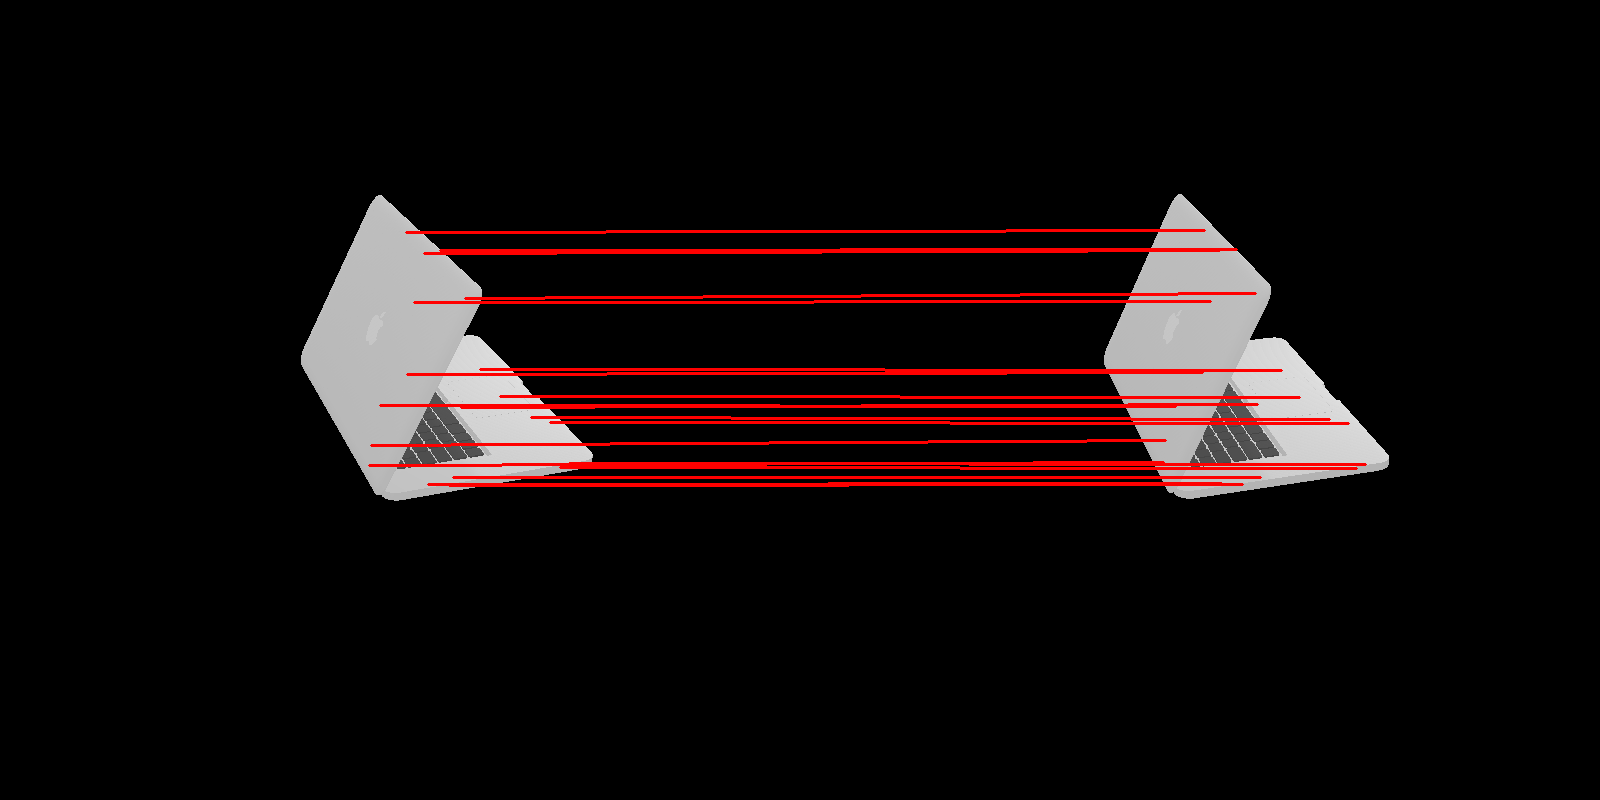

In [5]:
display(Image.fromarray(out_vis))

In [81]:
kpts1.shape

torch.Size([50, 2])

In [8]:
img_0.name.split('.')[0]

'0000'